In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# 1. Load Fashion MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 2. Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
# 3. Flatten 28x28 images into 784-dimensional vectors
x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

In [ ]:
# 4. Build the autoencoder
input_img = keras.Input(shape=(784,))

In [ ]:
# Encoder: compress 784 pixels into 64 values
encoded = layers.Dense(64, activation="relu")(input_img)

In [ ]:
# Decoder: reconstruct the 784-pixel image
decoded = layers.Dense(784, activation="sigmoid")(encoded)

In [ ]:

# Complete autoencoder
autoencoder = keras.Model(input_img, decoded)


In [ ]:
# 5. Compile the model
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [ ]:
# 6. Train for 5 epochs
autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.3906 - val_loss: 0.3278
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3145 - val_loss: 0.3077
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2998 - val_loss: 0.2968
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2905 - val_loss: 0.2895
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.2849 - val_loss: 0.2851


In [ ]:
# 7. Reconstruct a test image
reconstructed = autoencoder.predict(x_test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
# 8. Display original and reconstructed images side by side
index = 0

plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

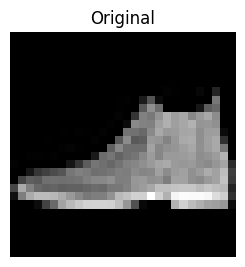

In [ ]:
# Original image
plt.subplot(1, 2, 1)
plt.imshow(x_test[index], cmap="gray")
plt.title("Original")
plt.axis("off")

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

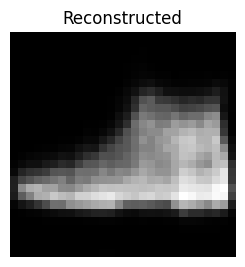

In [ ]:
# Reconstructed image
plt.subplot(1, 2, 2)
plt.imshow(reconstructed[index].reshape(28, 28), cmap="gray")
plt.title("Reconstructed")
plt.axis("off")